<a href="https://colab.research.google.com/github/AdityaWarrier2006/PINN-1D-Heat-Fourier_Law/blob/main/1D_IPINN_Parameter_Discovery.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import os

# Install DeepXDE using notebook magic
%pip install deepxde
# Set backend before importing DeepXDE
os.environ["DDE_BACKEND"] = "pytorch"
import deepxde as dde


In [5]:
!wget https://github.com/AdityaWarrier2006/PINN-1D-Heat-Fourier_Law/raw/refs/heads/main/get_data.py
!wget https://github.com/AdityaWarrier2006/PINN-1D-Heat-Fourier_Law/raw/refs/heads/main/define_system.py
!wget https://github.com/AdityaWarrier2006/PINN-1D-Heat-Fourier_Law/raw/refs/heads/main/train_inverse_PINN.py

--2026-09-12 09:14:32--  https://github.com/AdityaWarrier2006/PINN-1D-Heat-Fourier_Law/raw/refs/heads/main/get_data.py
Resolving github.com (github.com)... 140.82.112.3
Connecting to github.com (github.com)|140.82.112.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/AdityaWarrier2006/PINN-1D-Heat-Fourier_Law/refs/heads/main/get_data.py [following]
--2026-09-12 09:14:32--  https://raw.githubusercontent.com/AdityaWarrier2006/PINN-1D-Heat-Fourier_Law/refs/heads/main/get_data.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1366 (1.3K) [text/plain]
Saving to: ‘get_data.py.1’

get_data.py.1       100%[===================>]   1.33K  --.-KB/s    in 0s      

2026-09-12 09:14:32 (87.4 MB/s) - ‘get_d

File already exists...
Compiling model...
'compile' took 0.002656 s

Starting Adam Optimization (lr=0.001, iters=15000)...
Training model...

0         [3.37e-01, 2.30e+03, 1.07e+03, 1.11e+05]    [3.37e-01, 2.30e+03, 1.07e+03, 1.11e+05]    []  
1000      [2.84e+01, 1.24e+01, 6.05e+02, 2.44e+02]    [2.84e+01, 1.24e+01, 6.05e+02, 2.44e+02]    []  
2000      [8.64e+01, 1.02e+01, 5.02e+02, 1.78e+02]    [8.64e+01, 1.02e+01, 5.02e+02, 1.78e+02]    []  
3000      [1.05e+02, 1.05e+01, 4.47e+02, 1.67e+02]    [1.05e+02, 1.05e+01, 4.47e+02, 1.67e+02]    []  
4000      [9.45e+01, 1.10e+01, 3.95e+02, 1.58e+02]    [9.45e+01, 1.10e+01, 3.95e+02, 1.58e+02]    []  
5000      [9.43e+01, 1.07e+01, 3.54e+02, 1.50e+02]    [9.43e+01, 1.07e+01, 3.54e+02, 1.50e+02]    []  
6000      [1.00e+02, 9.04e+00, 3.25e+02, 1.41e+02]    [1.00e+02, 9.04e+00, 3.25e+02, 1.41e+02]    []  
7000      [1.24e+02, 8.24e+00, 2.46e+02, 1.15e+02]    [1.24e+02, 8.24e+00, 2.46e+02, 1.15e+02]    []  
8000      [1.41e+02, 6.28e+00, 1.7

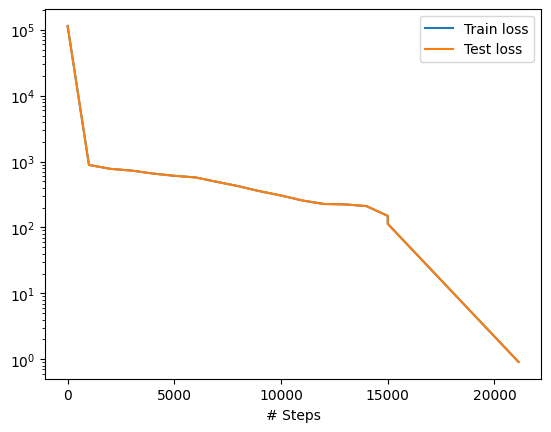

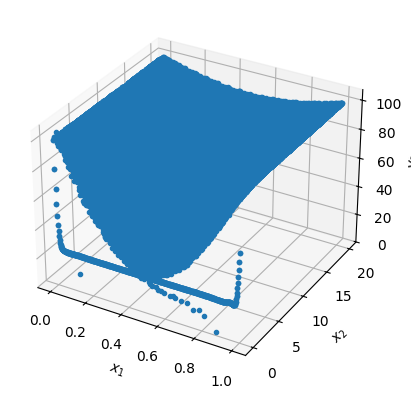

In [6]:
import train_inverse_PINN as train
import define_system
import get_data

# 1. Load data & set up system
observe_x, observe_u, observe_bc = get_data.get_data()
data = define_system.build_pinn_data(observe_x, observe_u)

# 2. Train model using default/custom parameters
args = train.parse_args()

model, losshistory, train_state = train.train_inverse_pinn(
    data=data,
    alpha=define_system.alpha,
    adam_lr=0.001,
    adam_iters=15000
)

In [ ]:
print("Final alpha value:", define_system.alpha.numpy())